In [1]:
import os
import uuid
import imageio
import numpy as np
import torch
from IPython.display import Image as ImageDisplay
import sys
PATH = os.getcwd()
module_dir = os.path.abspath(f"{PATH}/../../sam-3d-objects/notebook/")
sys.path.append(module_dir)
from inference import Inference, ready_gaussian_for_video_rendering, load_image, load_mask, display_image, make_scene, render_video, interactive_visualizer
import imageio.v3 as iio
from pytorch3d.transforms import quaternion_to_matrix, Transform3d

/home/haihong/miniconda3/envs/sam3d-objects/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Warp 1.11.1 initialized:
   CUDA Toolkit 12.9, Driver 12.8
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX 2000 Ada Generation" (16 GiB, sm_89, mempool enabled)
   Kernel cache:
     /home/haihong/.cache/warp/1.11.1


2026-03-31 11:42:59.396 | INFO     | sam3d_objects.pipeline.inference_pipeline:set_attention_backend:15 - GPU name is NVIDIA RTX 2000 Ada Generation


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


2026-03-31 11:43:01.475 | INFO     | sam3d_objects.model.backbone.tdfy_dit.modules.sparse:__from_env:39 - [SPARSE] Backend: spconv, Attention: sdpa
2026-03-31 11:43:03.878 | INFO     | sam3d_objects.model.backbone.tdfy_dit.modules.attention:__from_env:30 - [ATTENTION] Using backend: sdpa


[SPARSE][CONV] spconv algo: auto


2026-03-31 11:43:04.442 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-03-31 11:43:04.442 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 


In [2]:
PATH = os.getcwd()
TAG = "hf"
config_path = f"{PATH}/../../sam-3d-objects/checkpoints/{TAG}/pipeline.yaml"
inference = Inference(config_path, compile=False)

2026-03-31 11:43:04.473 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
/home/haihong/miniconda3/envs/sam3d-objects/lib/python3.11/site-packages/moge/model/v1.py:171: UserWarning: The following deprecated/invalid arguments are ignored: {'output_mask': True, 'split_head': True}
  warnings.warn(f"The following deprecated/invalid arguments are ignored: {deprecated_kwargs}")
2026-03-31 11:43:09.925 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-03-31 11:43:09.927 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:98 - self.device: cuda
2026-03-31 11:43:09.927 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:99 - CUDA_VISIBLE_DEVICES: None
2026-03-31 11:43:09.927 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:100 - Actually using GPU: 0
2026-03-31 11:43:09.928 | INFO   

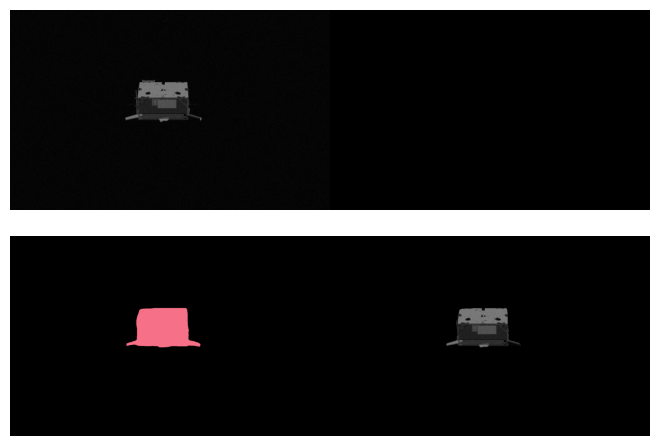

In [17]:
import cv2

IMAGE_PATH = f"{PATH}/../../tracking_dataset/shirtv1/roe1/synthetic/images/img000002.jpg"
MASK_PATH = f"{PATH}/../../tracking_dataset/shirtv1/roe1/lightbox/masks/img000002.png"

image_gry = load_image(IMAGE_PATH)
image = cv2.cvtColor(image_gry, cv2.COLOR_GRAY2RGB)
mask = load_mask(MASK_PATH)
display_image(image, [mask,])

In [18]:
outputs = inference(image, mask, seed=42)

2026-03-31 11:57:09.917 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:662 - Sampling sparse structure: inference_steps=25, strength=7, interval=[0, 500], rescale_t=3, cfg_strength_pm=0.0
2026-03-31 11:57:09.918 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:631 - Running condition embedder ...
2026-03-31 11:57:10.216 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:635 - Condition embedder finishes!
2026-03-31 11:57:32.741 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:712 - Downsampled coords from 21198 to 16396
2026-03-31 11:57:32.823 | INFO     | sam3d_objects.pipeline.inference_pipeline_pointmap:run:368 - Rescaling scale by 1 after downsampling
2026-03-31 11:57:32.824 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_slat:742 - Sampling sparse latent: inference_steps=25, strength=1, interval=[0, 500], rescale_t=1
2026-03-31 11:57:32.824 | INFO     | sam

In [19]:
save_path = f"{PATH}/../shirt_results/sam3d_object_cache.pt"
torch.save(outputs, save_path)

In [20]:
outputs = torch.load(f"{PATH}/../shirt_results/sam3d_object_cache.pt")
IMAGE_NAME = "img000002"

scene_gs = make_scene(*[outputs,])
scene_gs = ready_gaussian_for_video_rendering(scene_gs,fix_alignment=False)

# export gaussian splatting (as point cloud)
scene_gs.save_ply(f"{PATH}/../shirt_results/{IMAGE_NAME}.ply")

video = render_video(
    scene_gs,
    r=1,
    fov=60,
    resolution=512,
)["color"]
 
# save video as gif
imageio.mimsave(
    os.path.join(f"{PATH}/../shirt_results/{IMAGE_NAME}.gif"),
    video,
    format="GIF",
    duration=1000 / 30,  # default assuming 30fps from the input MP4
    loop=0,  # 0 means loop indefinitely
)

# notebook display
ImageDisplay(url=f"{PATH}/../shirt_results/{IMAGE_NAME}.gif?cache_invalidator={uuid.uuid4()}",)

/tmp/ipykernel_43626/2947077319.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  outputs = torch.load(f"{PATH}/../shirt_results/sam3d_object_cache.pt")
Rendering: 300it [

In [21]:
module_dir = os.path.abspath(f"{PATH}/../")
if module_dir not in sys.path:
    sys.path.append(module_dir)

from alignment_pipeline import (
    apply_moge_transform, estimate_transform, 
    extract_corresponding_points, transform_mesh_data,
    get_o3d_geometries, visualize_all_overlays
)

outputs = torch.load(f"{PATH}/../shirt_results/sam3d_object_cache.pt")
mesh = outputs["glb"].copy()
aligned_mesh = apply_moge_transform(mesh, outputs)

/tmp/ipykernel_43626/857694759.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  outputs = torch.load(f"{PATH}/../shirt_results/sam3d_object_cache.pt")


torch.Size([4585, 3])


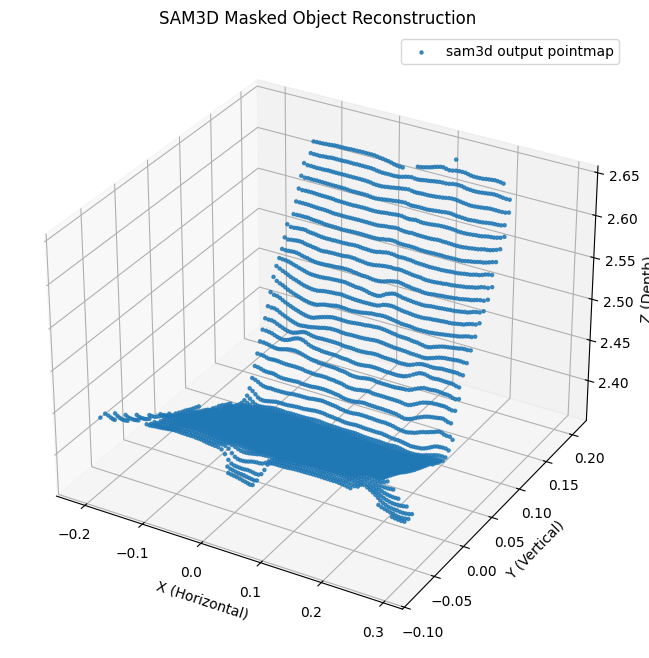

In [29]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
# Set labels
ax.set_xlabel('X (Horizontal)')
ax.set_ylabel('Y (Vertical)')
ax.set_zlabel('Z (Depth)')
ax.set_title('SAM3D Masked Object Reconstruction')
points = outputs.get('pointmap')
binary_mask = torch.from_numpy(mask)
mask_rescaled = F.interpolate(
    binary_mask.unsqueeze(0).unsqueeze(0).float(), 
    size=(points.shape[0], points.shape[1]), 
    mode='nearest'
).squeeze()
y_indices, x_indices = torch.where(mask_rescaled > 0)
filtered_points = points[y_indices, x_indices].reshape(-1, 3)
points_sampled = filtered_points[::]
print(points_sampled.shape)

xs, ys, zs = points_sampled[:, 0], points_sampled[:, 1], points_sampled[:, 2]
img = ax.scatter(xs, ys, zs, label=f'sam3d output pointmap', s=5, alpha=0.8)
    
ax.legend()
plt.show()

In [30]:
import open3d as o3d
import torch.nn.functional as F
geometries = []

points = outputs.get('pointmap')
colors = outputs.get('pointmap_colors')

binary_mask = torch.from_numpy(mask)
mask_rescaled = F.interpolate(
    binary_mask.unsqueeze(0).unsqueeze(0).float(), 
    size=(points.shape[0], points.shape[1]), 
    mode='nearest'
).squeeze()
y_indices, x_indices = torch.where(mask_rescaled > 0)
y_indices = y_indices.to(points.device)
x_indices = x_indices.to(points.device)
filtered_points = points[y_indices, x_indices]
filtered_colors = colors[y_indices, x_indices]
filtered_points[:, 0] = -filtered_points[:, 0]
filtered_points[:, 1] = -filtered_points[:, 1]
flat_points = filtered_points.reshape(-1, 3)
flat_colors = filtered_colors.reshape(-1, 3)
if flat_colors.max() > 1.0:
    flat_colors = flat_colors / 255.0
valid_idx = ~(flat_points == 0).all(dim=1)
final_points = flat_points[valid_idx]
final_colors = flat_colors[valid_idx]
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(final_points)
pcd.colors = o3d.utility.Vector3dVector(final_colors)
geometries.append(pcd)

mesh_o3d = o3d.geometry.TriangleMesh()
mesh_o3d.vertices = o3d.utility.Vector3dVector(np.asarray(outputs["glb"].vertices))
mesh_o3d.triangles = o3d.utility.Vector3iVector(np.asarray(outputs["glb"].faces))
mesh_o3d.compute_vertex_normals()
mesh_o3d.paint_uniform_color([1, 0, 0])
geometries.append(mesh_o3d)

aligned_mesh_o3d = o3d.geometry.TriangleMesh()
aligned_mesh_o3d.vertices = o3d.utility.Vector3dVector(np.asarray(aligned_mesh.vertices))
aligned_mesh_o3d.triangles = o3d.utility.Vector3iVector(np.asarray(aligned_mesh.faces))
aligned_mesh_o3d.compute_vertex_normals()
aligned_mesh_o3d.paint_uniform_color([0, 1, 0])
geometries.append(aligned_mesh_o3d)

origin = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.5)
geometries.append(origin)
o3d.visualization.draw_geometries(geometries)